<a href="https://colab.research.google.com/github/ziem-branchereau/us-recession-probit-model/blob/main/recession_probit_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Data and Yield Spread Calculation

In [10]:
import datetime
import pandas as pd
import pandas_datareader.data as web

# FRED ingestion: 10Y/2Y yields and NBER recession dates
start_date = datetime.datetime(1976, 6, 1)
tickers = ["DGS10", "DGS2", "USREC"]
raw_data = web.DataReader(tickers, "fred", start=start_date)

# Month-end alignment (business days)
df_monthly = raw_data.resample("ME").last().ffill().dropna()
df_monthly["Spread"] = df_monthly["DGS10"] - df_monthly["DGS2"]

df_monthly.tail()

,DGS10,DGS2,USREC,Spread
DATE,,,,
2026-05-31,4.45,3.98,0.0,0.47
2026-06-30,4.44,4.14,0.0,0.30
2026-07-31,4.75,4.28,0.0,0.47
2026-08-31,4.75,4.34,0.0,0.41
2026-09-30,4.77,4.34,0.0,0.43


## 2. Econometric Estimation: Estrella & Mishkin Probit Model

In [19]:
import statsmodels.api as sm

# 12-month forward horizon to replicate Estrella & Mishkin (1998)
df_monthly["USREC_lead12"] = df_monthly["USREC"].shift(-12)
train_df = df_monthly.dropna(subset=["USREC_lead12"]).copy()

y = train_df["USREC_lead12"]
X = sm.add_constant(train_df[["Spread"]])

probit_model = sm.Probit(y, X).fit()
print(probit_model.summary())

Optimization terminated successfully.
         Current function value: 0.267725
         Iterations 7
                          Probit Regression Results                           
Dep. Variable:           USREC_lead12   No. Observations:                  592
Model:                         Probit   Df Residuals:                      590
Method:                           MLE   Df Model:                            1
Date:                Mon, 07 Sep 2026   Pseudo R-squ.:                  0.1649
Time:                        02:12:33   Log-Likelihood:                -158.49
converged:                       True   LL-Null:                       -189.80
Covariance Type:            nonrobust   LLR p-value:                 2.518e-15
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9376      0.084    -11.210      0.000      -1.102      -0.774
Spread        -0.7197      0.

## 3. Historical Probability Estimation and Visualization

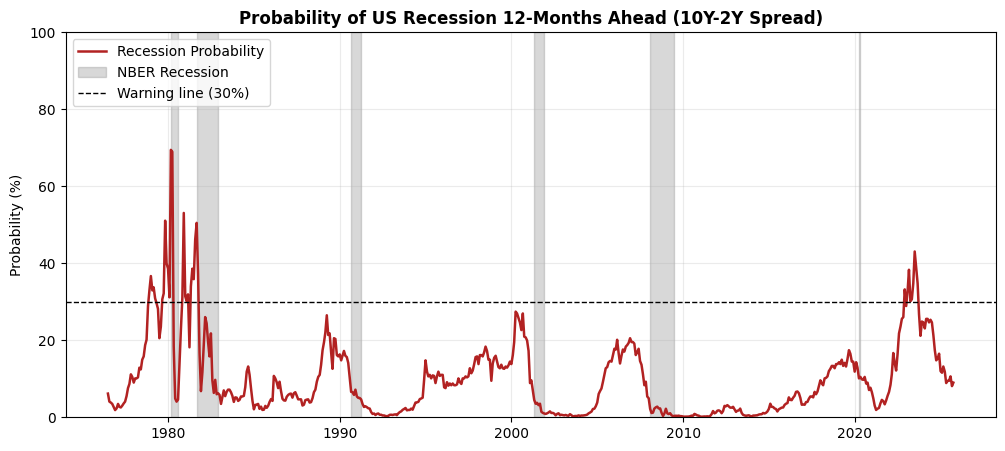

In [20]:
import matplotlib.pyplot as plt

train_df.loc[:, "Prob_Recession"] = probit_model.predict(X) * 100

plt.figure(figsize=(12, 5))
plt.plot(
    train_df.index,
    train_df["Prob_Recession"],
    color="firebrick",
    lw=1.8,
    label="Recession Probability",
)
plt.fill_between(
    train_df.index,
    0,
    100,
    where=(df_monthly.loc[train_df.index, "USREC"] == 1),
    color="grey",
    alpha=0.3,
    label="NBER Recession",
)

# Warning threshold from Estrella & Mishkin (1998)
plt.axhline(
    30, color="black", linestyle="--", linewidth=1, label="Warning line (30%)"
)

plt.title(
    "Probability of US Recession 12-Months Ahead (10Y-2Y Spread)",
    fontweight="bold",
)
plt.ylabel("Probability (%)")
plt.ylim(0, 100)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.25)

plt.savefig("historical_recession_prob.png", dpi=300, bbox_inches="tight")
plt.show()


## 4. Current Macro Diagnostic & Forward Projection

In [13]:
# Out-of-sample forecast on the latest 12 months
recent = df_monthly.tail(12).copy()
X_recent = sm.add_constant(recent[["Spread"]])
recent["Recession_Prob"] = probit_model.predict(X_recent) * 100

# Latest macro reading
latest_date = recent.index[-1].strftime("%B %Y")
latest_spread = recent["Spread"].iloc[-1]
latest_prob = recent["Recession_Prob"].iloc[-1]


print("=" * 42)
print("CURRENT MACRO | 12M FORWARD PROBIT ")
print("=" * 42)
print(f"As of: {latest_date}")
print(f"10Y-2Y Spread: {latest_spread:.2f}%")
print(f"12M Recession Probability: {latest_prob:.1f}%")
print("=" * 42)

CURRENT MACRO | 12M FORWARD PROBIT 
As of: September 2026
10Y-2Y Spread: 0.43%
12M Recession Probability: 10.6%


## 5. Out-of-Sample Validation & Performance Metrics (2000-Present)

In [14]:
from sklearn.metrics import roc_auc_score, brier_score_loss


valid_df = df_monthly.dropna(subset=["USREC_lead12"]).copy()


split_date = "1999-12-31"
train_df = valid_df.loc[:split_date].copy()
test_df = valid_df.loc["2000-01-01":].copy()


X_train = sm.add_constant(train_df[["Spread"]])
y_train = train_df["USREC_lead12"]

X_test = sm.add_constant(test_df[["Spread"]])
y_test = test_df["USREC_lead12"]


oos_model = sm.Probit(y_train, X_train).fit(disp=0)

test_df["Prob_OOS"] = oos_model.predict(X_test)


auc_score = roc_auc_score(y_test, test_df["Prob_OOS"])
brier_score = brier_score_loss(y_test, test_df["Prob_OOS"])

print(f"OOS AUC-ROC: {auc_score:.3f}")
print(f"OOS Brier Score: {brier_score:.3f}")

OOS AUC-ROC: 0.727
OOS Brier Score: 0.085


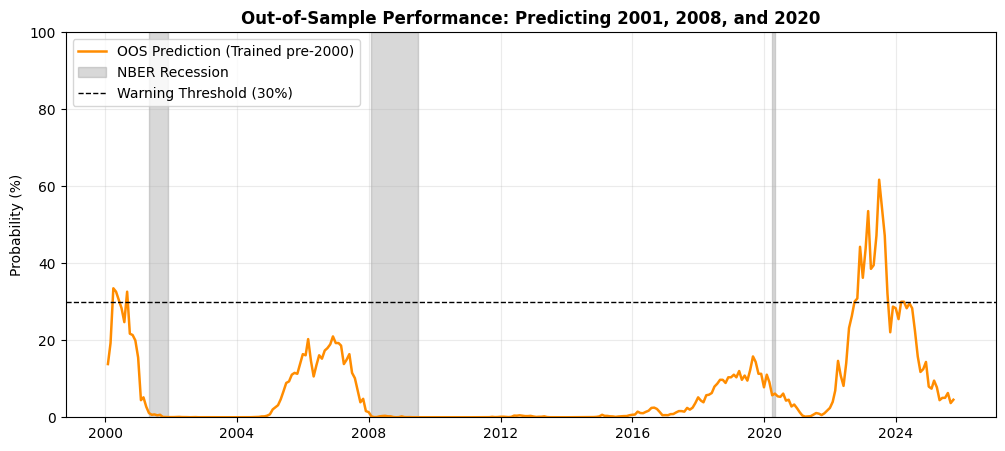

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# OOS prediction line
plt.plot(
    test_df.index,
    test_df["Prob_OOS"] * 100,
    color="darkorange",
    linewidth=1.8,
    label="OOS Prediction (Trained pre-2000)",
)

# NBER recession shading (actual historical dates)
plt.fill_between(
    test_df.index,
    0,
    100,
    where=(df_monthly.loc[test_df.index, "USREC"] == 1),
    color="grey",
    alpha=0.3,
    label="NBER Recession",
)

# 30% rule from Estrella & Mishkin
plt.axhline(
    30,
    color="black",
    linestyle="--",
    linewidth=1,
    label="Warning Threshold (30%)",
)

# chart
plt.title(
    "Out-of-Sample Performance: Predicting 2001, 2008, and 2020",
    fontweight="bold",
)
plt.ylabel("Probability (%)")
plt.ylim(0, 100)
plt.legend(loc="upper left")
plt.grid(True, alpha=0.25)

plt.savefig("oos_recession_plot.png", dpi=300, bbox_inches="tight")
plt.show()